## 1. Instalación de dependencias

Este comando instala las librerías necesarias para descargar comentarios de YouTube y procesar datos


In [2]:
!pip install youtube-comment-downloader nltk wordcloud

## 2. Carga de librerías

En esta sección se importan las librerías necesarias para el análisis de datos y procesamiento de texto

In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

from youtube_comment_downloader import YoutubeCommentDownloader

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 3. Obtención de datos

Se descargan comentarios de un video de YouTube utilizando una herramienta automatizada y se limitan a 200 comentarios

In [8]:
downloader = YoutubeCommentDownloader()

url = "https://www.youtube.com/watch?v=mQJ2AR7BkQs"

comentarios = []

for comment in downloader.get_comments_from_url(url):
    comentarios.append(comment['text'])

df = pd.DataFrame(comentarios, columns=["comentario"])

df = df.head(200)

df.head()

,comentario
0,¡Bienvenidos al 2026! 🎉 El vídeo sigue siendo ...
1,Totalmente de acuerdo y lo digo porque tengo l...
2,4:50 a mi mi android si me lo hace.. pero no e...
3,Que grande esto es literal. Después de ser usu...
4,Llevo con iphone varios años pero deseando vol...


## 4. Limpieza de datos

Se realiza la limpieza de los comentarios eliminando caracteres especiales, números y convirtiendo el texto a minúsculas.

In [9]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
    return texto

df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)

df.head()

,comentario,comentario_limpio
0,¡Bienvenidos al 2026! 🎉 El vídeo sigue siendo ...,bienvenidos al el vídeo sigue siendo vigent...
1,Totalmente de acuerdo y lo digo porque tengo l...,totalmente de acuerdo y lo digo porque tengo l...
2,4:50 a mi mi android si me lo hace.. pero no e...,a mi mi android si me lo hace pero no en apli...
3,Que grande esto es literal. Después de ser usu...,que grande esto es literal después de ser usua...
4,Llevo con iphone varios años pero deseando vol...,llevo con iphone varios años pero deseando vol...


## 5. Tokenización y eliminación de stopwords

Se separan los textos en palabras (tokens) y se eliminan palabras vacías

In [10]:
stop_words = set(stopwords.words('spanish'))

def procesar_texto(texto):
    palabras = word_tokenize(texto)
    palabras = [p for p in palabras if p not in stop_words]
    return palabras

df["tokens"] = df["comentario_limpio"].apply(procesar_texto)

df.head()

,comentario,comentario_limpio,tokens
0,¡Bienvenidos al 2026! 🎉 El vídeo sigue siendo ...,bienvenidos al el vídeo sigue siendo vigent...,"[bienvenidos, vídeo, sigue, siendo, vigente, a..."
1,Totalmente de acuerdo y lo digo porque tengo l...,totalmente de acuerdo y lo digo porque tengo l...,"[totalmente, acuerdo, digo, dos, iphone, pro, ..."
2,4:50 a mi mi android si me lo hace.. pero no e...,a mi mi android si me lo hace pero no en apli...,"[android, si, hace, aplicaciones, banca, hecho..."
3,Que grande esto es literal. Después de ser usu...,que grande esto es literal después de ser usua...,"[grande, literal, después, ser, usuario, iphon..."
4,Llevo con iphone varios años pero deseando vol...,llevo con iphone varios años pero deseando vol...,"[llevo, iphone, varios, años, deseando, volver..."


## 6. Clasificación de sentimientos

Se clasifican los comentarios en positivos, negativos o neutrales utilizando listas de palabras clave.

In [11]:
positivas = ["bueno", "excelente", "increíble", "perfecto", "genial", "feliz"]
negativas = ["malo", "terrible", "horrible", "odio", "pésimo", "asco", "mal"]

def clasificar_sentimiento(texto):
    texto = texto.lower()
    if any(p in texto for p in positivas):
        return "positivo"
    elif any(n in texto for n in negativas):
        return "negativo"
    else:
        return "neutral"

df["sentimiento"] = df["comentario"].apply(clasificar_sentimiento)

df.head()

,comentario,comentario_limpio,tokens,sentimiento
0,¡Bienvenidos al 2026! 🎉 El vídeo sigue siendo ...,bienvenidos al el vídeo sigue siendo vigent...,"[bienvenidos, vídeo, sigue, siendo, vigente, a...",neutral
1,Totalmente de acuerdo y lo digo porque tengo l...,totalmente de acuerdo y lo digo porque tengo l...,"[totalmente, acuerdo, digo, dos, iphone, pro, ...",neutral
2,4:50 a mi mi android si me lo hace.. pero no e...,a mi mi android si me lo hace pero no en apli...,"[android, si, hace, aplicaciones, banca, hecho...",neutral
3,Que grande esto es literal. Después de ser usu...,que grande esto es literal después de ser usua...,"[grande, literal, después, ser, usuario, iphon...",neutral
4,Llevo con iphone varios años pero deseando vol...,llevo con iphone varios años pero deseando vol...,"[llevo, iphone, varios, años, deseando, volver...",neutral


## ANÁLISIS 1: Conteo de comentarios positivos y negativos

Se realiza un conteo de los comentarios clasificados por tipo de sentimiento.

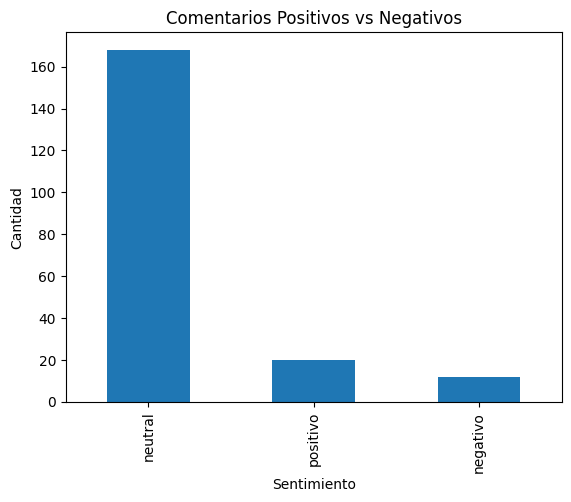

In [12]:
conteo = df["sentimiento"].value_counts()

conteo.plot(kind='bar')
plt.title("Comentarios Positivos vs Negativos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.show()

## ANÁLISIS 2: Palabras más frecuentes

Se identifican las palabras más utilizadas en todos los comentarios.

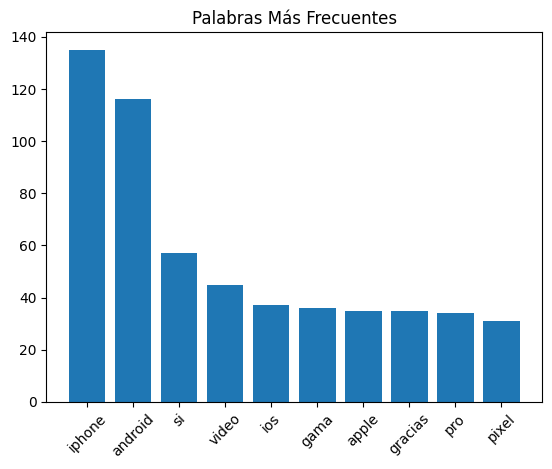

In [13]:
todas_palabras = sum(df["tokens"], [])
frecuencia = Counter(todas_palabras)

frecuentes = dict(frecuencia.most_common(10))

plt.bar(frecuentes.keys(), frecuentes.values())
plt.xticks(rotation=45)
plt.title("Palabras Más Frecuentes")
plt.show()

## ANÁLISIS 3: Palabras en comentarios positivos vs negativos

Se comparan las palabras más frecuentes en comentarios positivos y negativos.

In [14]:
positivos = df[df["sentimiento"] == "positivo"]
negativos = df[df["sentimiento"] == "negativo"]

palabras_pos = sum(positivos["tokens"], [])
palabras_neg = sum(negativos["tokens"], [])

print("Top positivas:", Counter(palabras_pos).most_common(5))
print("Top negativas:", Counter(palabras_neg).most_common(5))

Top positivas: [('iphone', 30), ('android', 25), ('si', 19), ('bueno', 12), ('cosas', 11)]
Top negativas: [('q', 14), ('iphone', 13), ('cosas', 10), ('android', 10), ('ios', 6)]


## ANÁLISIS 4: Nube de palabras

Se generan nubes de palabras para visualizar las palabras más representativas en cada tipo de sentimiento.

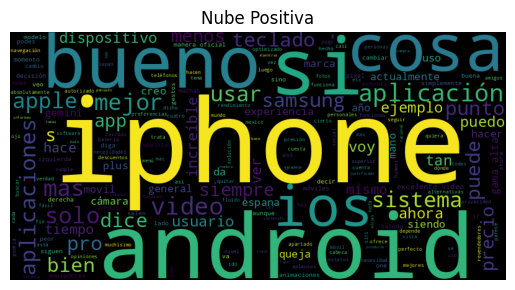

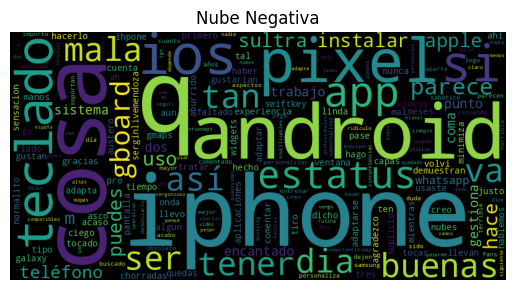

In [15]:
texto_pos = " ".join(palabras_pos)
texto_neg = " ".join(palabras_neg)

wordcloud_pos = WordCloud(width=800, height=400).generate(texto_pos)
wordcloud_neg = WordCloud(width=800, height=400).generate(texto_neg)

plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("Nube Positiva")
plt.show()

plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("Nube Negativa")
plt.show()

## Conclusión

En este trabajo fueron analizados comentarios reales obtenidos de YouTube para identificar sentimientos positivos, negativos y neutrales en el que se aplicaron técnicas de limpieza y procesamiento de texto para mejorar la calidad del análisis. Los resultados muestran que es posible identificar patrones en la opinión de los usuarios mediante el uso de herramientas de análisis de datos.